# DEF-D Fysieke Ontwerpopdracht 5 Invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 32     |  |
| :-------------|:-------------|
| Tijn de Nooijer| 6387306 |
| Koen Gort| 6574963 |
| Hendrik de Mulder| 6350143 |

## Opdracht 1: Planning.

| Planning Groep: 32     |Tijdstip / Tijdspanne  | door wie  |
|---|---|---|
| Arduino testen| 10:30-11:00 | Koen |
| ontwerp-eis berekenen| 10:30-11:00 | Hendrik & Tijn|
| Eerste iteratie  | 11:00-12:30 | hele groep |
| verdere iteraties | 13:30-14:30| hele groep |
| Mijlpaal 1 | 14:30-16:00 klaar om in te leveren| ---|
| Pauze 1| 12:30-13:30 | hele groep |

Run onderstaande cel om alle benodigde libraries te laden. Mogelijk voeg je er zelf nog een aantal toe later vandaag. 

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
import math

## Opdracht 2a: Opsplitsen taak 1: Arduino
Vul onderstaande tabel in:

| onderwerp    | antwoord  |
|---|---|
| hoe moeilijk (schaal 1 - 10) | 6 |
| hoe lang voor één meting | 3min |
| verwacht nauwkeurigheid meting | +-0.1 |

## Opdracht 2b: Opsplitsen taak 2: afleiding ontwerpeis

In [2]:
# Bereken hier je benodigde kantelfrequentie
w=10*np.pi
w_0=w/2
print(w_0)

15.707963267948966


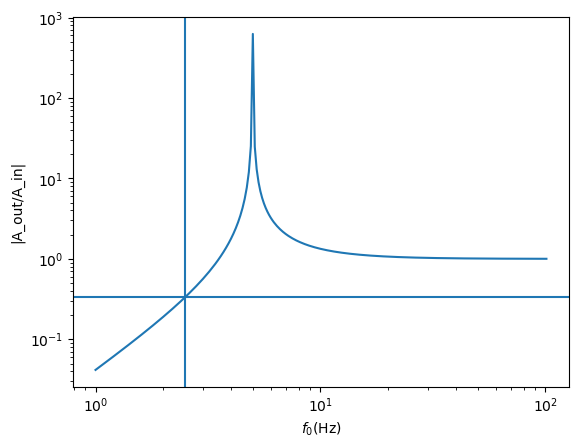

In [3]:
# Voeg hier je plot in.
f=w/(2*np.pi)
f_0 = np.linspace(1,101,1000)
def amplitudeoverdracht(f_0,f):
    return 1/(1-(f**2/f_0**2))
plt.figure()
plt.xscale("log")
plt.yscale("log")
plt.xlabel("$f_0$(Hz)")
plt.ylabel("|A_out/A_in|")
plt.plot(f_0,np.abs(amplitudeoverdracht(f_0,f)))
plt.axhline(1/3)
plt.axvline(w_0/(2*np.pi))

plt.show()

In [4]:
# Bereken hier de minimale Delta-x waarbij je aan de eis van de opdracht voldoet.
g = 9.81
dx = g/((w_0)**2)

print(dx)

0.039758432461253344


## Opdracht 3: Plot de grafiek.

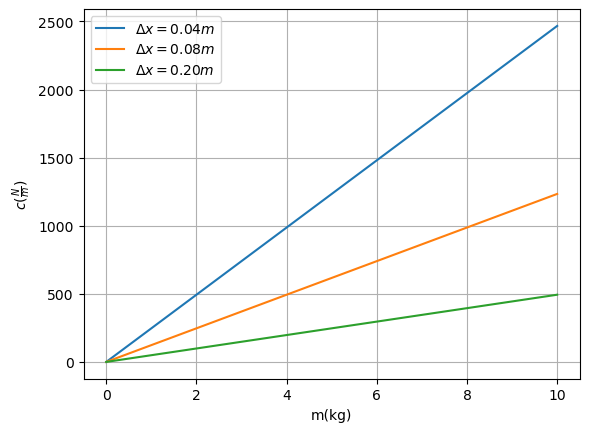

In [5]:
# Voeg hier je plot in. Lees goed de opdracht wat er in de grafiek moet staan!
# Het is ook handig om je grafiek op te slaan, doe dat door met plt.savefig().

def linfunc(x, a):
    return a*x 

x = np.linspace(0, 10, 1000)
g =9.81
plt.figure()
plt.plot(x, linfunc(x, g/dx), label= f'$ \\Delta x = {dx: .2f} m$')
plt.plot(x, linfunc(x, g/(2*dx)), label= f'$ \\Delta x = {2*dx: .2f} m$')
plt.plot(x, linfunc(x, g/(5*dx)), label= f'$ \\Delta x = {5*dx: .2f} m$')
plt.xlabel('m(kg)')
plt.ylabel('$ c(\\frac{N}{m}) $')
plt.legend()
plt.grid()
plt.show()


## Opdracht 4: Verander $\Delta x$.

We kunnen $\Delta x$ verhogen door:

- de veerconstante te variëren
- de massa te variëren

Vul onderstaande aan. Geef eventueel met tekst aan waarom je hiervoor gekozen hebt, als extra informatie richting de nakijkers. 

Als groep gaan we mikken op een $\Delta x$ van: 8 cm.


In [6]:
#youngs modulus
c=600
L= 0.1
A=0.002*0.01

E=(c*L)/A
print(E)

2999999.9999999995


## Opdracht 5: Schets.

##### schets opstelling: 
<img src="schets1.png" width="400">

## Opdracht 6: Beslissing evaluatie

Voldoet je ontwerp aan de eisen? Beantwoord de volgende vragen:

### Wat is de $\Delta x$ van je ontwerp?

**15cm**

### Wordt die $\Delta x$ behaald met je gekozen massa en veer?

**ja**

### hoeveel verder kan je massa-veer systeem nog uitrekken / indrukken?
Wat is de limiet aan je veer / verend materiaal voordat het niet meer lineair reageert volgens de wet van Hooke?

**totdat de elastieken breken, verder gedragen ze zich zo goed als lineair**

### Is dat genoeg om straks metingen te kunnen doen?
Hou er rekening mee dat je trillingen een amplitude in de orde grote van een paar centimeter gaan hebben, minder is met deze opzet moeilijk te realiseren.

**Daar houden we rekening mee**

### Gaat je ontwerp dus voldoen aan de eis?

**Ja dus**

Als je hier positief geantwoord heb, maak dan nog een keer een plot van amplitude overdracht (y-as) versus frequentie (x-as) zoals je hierboven ook al een keer gedaan heb, maar plot nu twee verschillende overdrachten in de grafiek: één die je al had: behorende bij de grens van de ontwerp-eis en één behorende bij je eigen ontwerp. Lees af dat je voor je ontwerp daadwerkelijk onder de eis grafiek zit op de kritieke frequentie!

Deze grafiek heb je later weer nodig om je gemeten punten aan toe te voegen. Ga daarna je massa-veer systeem daadwerkelijk bouwen.

Als je hier negatief geantwoord hebt, kopieer onder deze cel dan alle cellen van Synthese tot en met Evaluation & decision en doorloop dat deel van het ontwerp proces nogmaals.

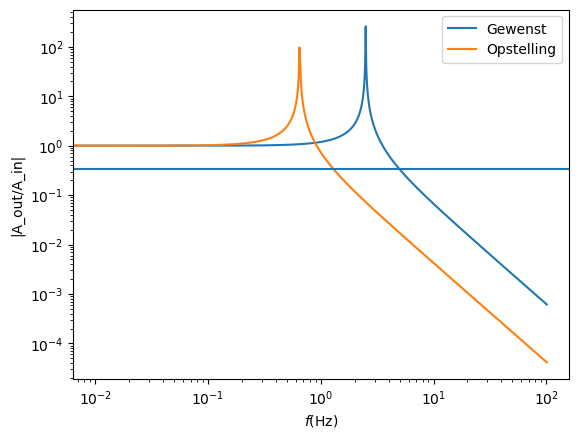

In [7]:
# Voeg hier je plot in.
f_02=(np.sqrt(25/1.5))/(2*np.pi)
f2 = np.linspace(0,101,10001)

f_0 = w_0/(2*np.pi)

def amplitudeoverdracht(f_0,f):
    return np.abs(1/(1-(f**2/f_0**2)))

plt.figure()
plt.xscale("log")
plt.yscale("log")
plt.plot(f2, amplitudeoverdracht(f_0, f2), label = 'Gewenst')
plt.plot(f2,np.abs(amplitudeoverdracht(f_02,f2)),label="Opstelling")
plt.axhline(1/3, label='')

plt.xlabel("$f$(Hz)")
plt.ylabel("|A_out/A_in|")
plt.legend()
plt.show()



## Opdracht 7: Plotten maar

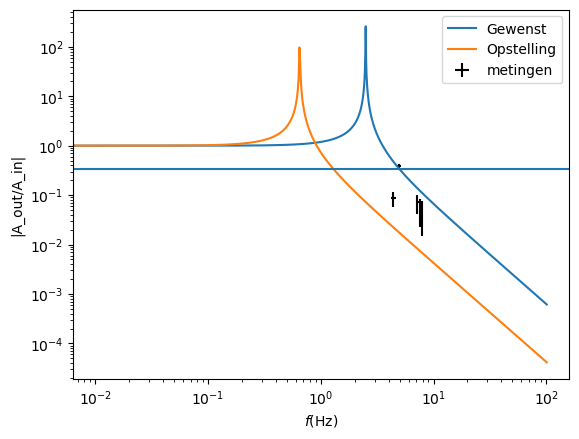

In [8]:
# Voeg hier je plots in.

verhoudingen = np.array([0.11/2.46, 0.17/3.26, 0.37/5.19, 0.29/3.31, 1.42/3.63 ])
frequenties = np.array([7.9, 7.6, 7.2, 4.4, 4.9])
plt.figure()
plt.xscale("log")
plt.yscale("log")

plt.errorbar(frequenties, verhoudingen, xerr=0.2 , yerr=0.03, fmt='None', ecolor='black',label='metingen')
plt.plot(f2, amplitudeoverdracht(f_0, f2), label = 'Gewenst')
plt.plot(f2,np.abs(amplitudeoverdracht(f_02,f2)),label="Opstelling")
plt.axhline(1/3, label='')

plt.xlabel("$f$(Hz)")
plt.ylabel("|A_out/A_in|")
plt.legend()
plt.show()



## Opdracht 8: Leerdoelen
Voeg hieronder zelf kopjes toe om aan te geven wat bij welk leerdoel hoort. 

## Opdracht 8: Leerdoel 1

#### Als je je figuren onderweg opgeslagen hebt, kan je ze hier invoegen:

<img src="Schets1.png" width="400">
De schets bewijst beheersing van leerdoel 1 dat we kunnen ontwerpen met iets wat de gegeven parameters kan behalen.

***Leerdoel 1: variabelen als ontwerpsvrijheidsgraden***

We kunnen $\Delta x$ verhogen door:

- de veerconstante te variëren
- de massa te variëren

Vul onderstaande aan. Geef eventueel met tekst aan waarom je hiervoor gekozen hebt, als extra informatie richting de nakijkers. 

Als groep gaan we mikken op een $\Delta x$ van: 8 cm.



## Opdracht 8: Leerdoel 2

<img src="Uiteindelijk_ontwerp.png" width="400">
Dit bewijst beheersing van leerdoel 2 aangezien met de gekozen parameters een goed resultaat is behaald.

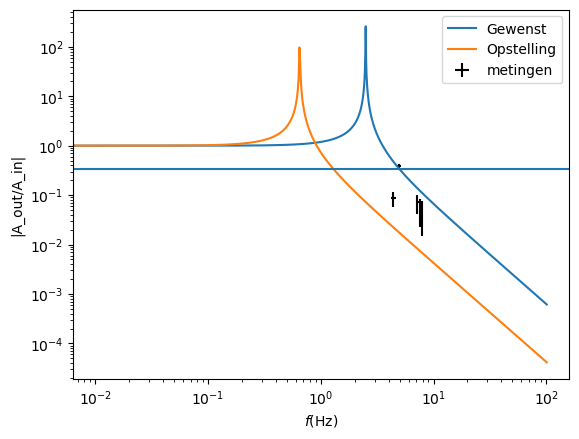

In [9]:
# Als je met Python je resultaten wil laten zien: voeg hier je code in.
# Voeg hier je plots in.

verhoudingen = np.array([0.11/2.46, 0.17/3.26, 0.37/5.19, 0.29/3.31, 1.42/3.63 ])
frequenties = np.array([7.9, 7.6, 7.2, 4.4, 4.9])
plt.figure()
plt.xscale("log")
plt.yscale("log")

plt.errorbar(frequenties, verhoudingen, xerr=0.2 , yerr=0.03, fmt='None', ecolor='black',label='metingen')
plt.plot(f2, amplitudeoverdracht(f_0, f2), label = 'Gewenst')
plt.plot(f2,np.abs(amplitudeoverdracht(f_02,f2)),label="Opstelling")
plt.axhline(1/3, label='')

plt.xlabel("$f$(Hz)")
plt.ylabel("|A_out/A_in|")
plt.legend()
plt.show()

Dit bewijst beheersing van leerdoel 2 aangezien met de gekozen parameters een goed resultaat is behaald.